# Outlier Analysis in Machine Learning 🎯

## What is an Outlier?

An **Outlier** is a data point that is significantly different from other observations in the dataset.

### Simple Definition 📚
Think of a class where most students scored 70-90, but one student scored 20. That 20 is an **OUTLIER** - it's very different from the rest.

### Visual Example

```
Normal Distribution:  10, 12, 11, 13, 12, 11, 10, 14, 11, 12
                      All values are between 10-14

With Outlier:        10, 12, 11, 13, 12, 100, 10, 14, 11, 12
                                         ↑
                                     OUTLIER! (100)
```

---

## Why Should We Care About Outliers? 🤔

### 1. **Skew Model Performance**
- Outliers can mislead ML models
- Models might learn wrong patterns
- Example: If one house costs $1M in a neighborhood of $300K homes, regression model gets confused

### 2. **Affect Statistics**
- Mean, standard deviation get distorted
- Example: Average income with billionaire in room ≠ true average income

### 3. **Indicate Data Errors**
- Sometimes outliers are just mistakes
- Example: Height recorded as 999 cm (should be 200 cm)

### 4. **Can Be Valuable**
- Sometimes outliers are important!
- Example: Detecting fraud, anomalies, defects

---

## Real-World Analogies 🏠

### Example 1: House Prices
```
Neighborhood houses: $300K, $310K, $305K, $320K, $315K
Outlier: $2M (luxury mansion)

Action: Remove or handle separately for fair pricing model
```

### Example 2: Student Scores
```
Class scores: 75, 78, 82, 79, 81, 80
Outlier: 10 (sick student, took test)

Action: Keep or mark separately (might be valid reason)
```

### Example 3: Body Weight
```
Class weights: 60kg, 65kg, 62kg, 68kg, 70kg
Outlier: 200kg (data entry error: should be 70kg)

Action: Fix the data error
```

EXAMPLE 1: UNDERSTANDING OUTLIERS - SIMPLE DATA

🎯 Scenario: Student Test Scores
--------------------------------------------------------------------------------

✅ Normal Scores (No Outlier):
[72, 75, 78, 80, 82, 85, 88, 90, 92, 95]
Mean: 83.70
Std Dev: 7.20
Min: 72, Max: 95

❌ Scores With Outlier (150 - abnormally high):
[72, 75, 78, 80, 82, 85, 88, 90, 92, 150]
Mean: 89.20
Std Dev: 21.17
Min: 72, Max: 150

💡 Notice how ONE outlier (150) changed:
   • Mean increased from 82 to 89.20
   • Max value from 95 to 150
   • This outlier distorts our understanding of the data!


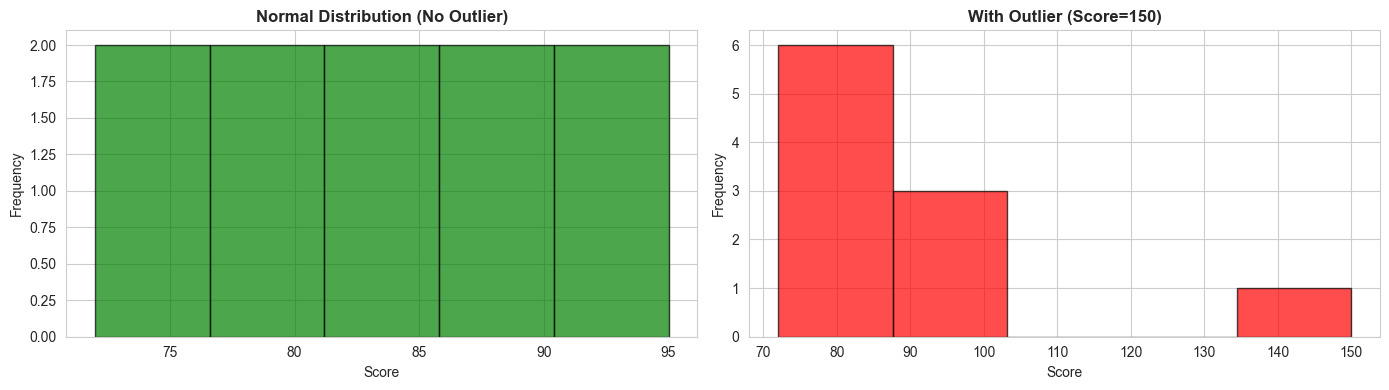


📊 Visual comparison shows the outlier clearly!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ============================================================================
# EXAMPLE 1: UNDERSTANDING OUTLIERS WITH SIMPLE DATA
# ============================================================================
print("=" * 80)
print("EXAMPLE 1: UNDERSTANDING OUTLIERS - SIMPLE DATA")
print("=" * 80)

print("\n🎯 Scenario: Student Test Scores")
print("-" * 80)

# Normal data (most students)
normal_scores = [72, 75, 78, 80, 82, 85, 88, 90, 92, 95]

# Data with an outlier
scores_with_outlier = [72, 75, 78, 80, 82, 85, 88, 90, 92, 150]

print("\n✅ Normal Scores (No Outlier):")
print(normal_scores)
print(f"Mean: {np.mean(normal_scores):.2f}")
print(f"Std Dev: {np.std(normal_scores):.2f}")
print(f"Min: {min(normal_scores)}, Max: {max(normal_scores)}")

print("\n❌ Scores With Outlier (150 - abnormally high):")
print(scores_with_outlier)
print(f"Mean: {np.mean(scores_with_outlier):.2f}")
print(f"Std Dev: {np.std(scores_with_outlier):.2f}")
print(f"Min: {min(scores_with_outlier)}, Max: {max(scores_with_outlier)}")

print("\n💡 Notice how ONE outlier (150) changed:")
print(f"   • Mean increased from 82 to {np.mean(scores_with_outlier):.2f}")
print(f"   • Max value from 95 to 150")
print(f"   • This outlier distorts our understanding of the data!")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(normal_scores, bins=5, color='green', alpha=0.7, edgecolor='black')
axes[0].set_title('Normal Distribution (No Outlier)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')

axes[1].hist(scores_with_outlier, bins=5, color='red', alpha=0.7, edgecolor='black')
axes[1].set_title('With Outlier (Score=150)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print("\n📊 Visual comparison shows the outlier clearly!")



EXAMPLE 2: DETECTING OUTLIERS - IQR METHOD

🎯 Scenario: Employee Monthly Salary
   Most employees earn $2000-5000, but need to find outliers
--------------------------------------------------------------------------------

📊 Salary Data:
    Employee_ID  Salary
0             1    2500
1             2    3000
2             3    2800
3             4    3200
4             5    2900
5             6    5500
6             7    3100
7             8    3500
8             9    3200
9            10    2800
10           11    3400
11           12    3100
12           13   50000
13           14    2900
14           15    3000
15           16    3200
16           17    3100
17           18    2950
18           19   15000
19           20    3200


🔍 STEP 1: Understanding IQR
--------------------------------------------------------------------------------
Q1 (25th percentile): $2937.50
   ↳ 25% of salaries are below this

Q3 (75th percentile): $3250.00
   ↳ 75% of salaries are below this

IQR (Inter

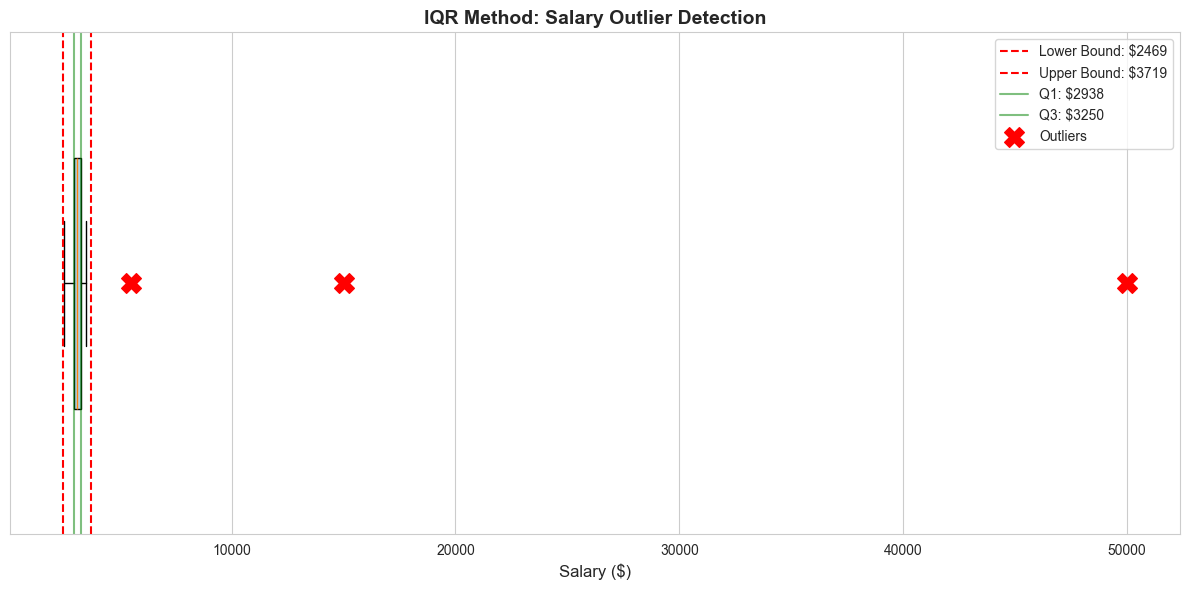


📊 Box plot shows outliers clearly as X marks!


In [2]:
# ============================================================================
# EXAMPLE 2: DETECTING OUTLIERS - IQR (INTERQUARTILE RANGE) METHOD
# ============================================================================
print("\n" + "=" * 80)
print("EXAMPLE 2: DETECTING OUTLIERS - IQR METHOD")
print("=" * 80)

print("\n🎯 Scenario: Employee Monthly Salary")
print("   Most employees earn $2000-5000, but need to find outliers")
print("-" * 80)

# Create salary data
salaries = pd.DataFrame({
    'Employee_ID': range(1, 21),
    'Salary': [2500, 3000, 2800, 3200, 2900, 5500, 3100, 3500, 3200, 2800,
               3400, 3100, 50000, 2900, 3000, 3200, 3100, 2950, 15000, 3200]
})

print("\n📊 Salary Data:")
print(salaries)

# Calculate IQR
print("\n\n🔍 STEP 1: Understanding IQR")
print("-" * 80)

Q1 = salaries['Salary'].quantile(0.25)  # 25th percentile
Q3 = salaries['Salary'].quantile(0.75)  # 75th percentile
IQR = Q3 - Q1

print(f"Q1 (25th percentile): ${Q1:.2f}")
print(f"   ↳ 25% of salaries are below this")

print(f"\nQ3 (75th percentile): ${Q3:.2f}")
print(f"   ↳ 75% of salaries are below this")

print(f"\nIQR (Interquartile Range): ${IQR:.2f}")
print(f"   ↳ Range of middle 50% of data")

# Calculate outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\n\n🔧 STEP 2: Calculate Outlier Bounds")
print("-" * 80)
print(f"Lower Bound: Q1 - 1.5×IQR = {Q1:.2f} - 1.5×{IQR:.2f} = ${lower_bound:.2f}")
print(f"Upper Bound: Q3 + 1.5×IQR = {Q3:.2f} + 1.5×{IQR:.2f} = ${upper_bound:.2f}")
print(f"\n✓ Any value OUTSIDE [{lower_bound:.2f}, {upper_bound:.2f}] is an OUTLIER")

# Identify outliers
outliers = salaries[(salaries['Salary'] < lower_bound) | (salaries['Salary'] > upper_bound)]

print(f"\n\n📍 STEP 3: Identify Outliers")
print("-" * 80)
if len(outliers) > 0:
    print(f"\nFound {len(outliers)} OUTLIERS:")
    print(outliers)
else:
    print("No outliers found")

print(f"\n💡 Meaning:")
print(f"   • Salaries below ${lower_bound:.2f} → Unusually LOW")
print(f"   • Salaries above ${upper_bound:.2f} → Unusually HIGH")
print(f"   • Employees 13, 19 have unusual salaries (CEO, VP?)")

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

# Box plot
bp = ax.boxplot(salaries['Salary'], vert=False, widths=0.5, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')

# Add bounds lines
ax.axvline(lower_bound, color='red', linestyle='--', label=f'Lower Bound: ${lower_bound:.0f}')
ax.axvline(upper_bound, color='red', linestyle='--', label=f'Upper Bound: ${upper_bound:.0f}')
ax.axvline(Q1, color='green', linestyle='-', alpha=0.5, label=f'Q1: ${Q1:.0f}')
ax.axvline(Q3, color='green', linestyle='-', alpha=0.5, label=f'Q3: ${Q3:.0f}')

# Mark outliers
if len(outliers) > 0:
    ax.scatter(outliers['Salary'], [1]*len(outliers), color='red', s=200, 
               marker='X', label='Outliers', zorder=5)

ax.set_xlabel('Salary ($)', fontsize=12)
ax.set_title('IQR Method: Salary Outlier Detection', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0.5, 1.5)
ax.set_yticks([])
plt.tight_layout()
plt.show()

print("\n📊 Box plot shows outliers clearly as X marks!")


In [ ]:
# ============================================================================
# EXAMPLE 3: Z-SCORE METHOD FOR OUTLIER DETECTION
# ============================================================================
print("\n" + "=" * 80)
print("EXAMPLE 3: Z-SCORE METHOD FOR OUTLIER DETECTION")
print("=" * 80)

print("\n🎯 Scenario: Student Heights in Centimeters")
print("-" * 80)

# Height data
heights = pd.DataFrame({
    'Student_ID': range(1, 21),
    'Height_cm': [165, 168, 170, 172, 169, 171, 170, 173, 168, 169,
                  167, 170, 220, 171, 168, 169, 350, 170, 169, 171]
})

print("\n📊 Height Data:")
print(heights)

# Calculate Z-Score
print("\n\n🔍 STEP 1: Understanding Z-Score")
print("-" * 80)

mean_height = heights['Height_cm'].mean()
std_height = heights['Height_cm'].std()

print(f"Mean Height: {mean_height:.2f} cm")
print(f"Std Deviation: {std_height:.2f} cm")

print(f"\n💡 Z-Score Formula: (Value - Mean) / Std Dev")
print(f"   • Z-Score = 0 → Value is at mean")
print(f"   • Z-Score = 2 → Value is 2 std devs above mean")
print(f"   • Z-Score = -2 → Value is 2 std devs below mean")

# Calculate Z-scores
heights['Z_Score'] = np.abs(stats.zscore(heights['Height_cm']))

print(f"\n\n🔧 STEP 2: Calculate Z-Scores for All Heights")
print("-" * 80)
print(heights[['Student_ID', 'Height_cm', 'Z_Score']])

# Identify outliers (|Z-Score| > 3)
threshold = 3
outliers_z = heights[heights['Z_Score'] > threshold]

print(f"\n\n📍 STEP 3: Identify Outliers (|Z-Score| > {threshold})")
print("-" * 80)
if len(outliers_z) > 0:
    print(f"\nFound {len(outliers_z)} OUTLIERS with Z-Score > {threshold}:")
    print(outliers_z)
else:
    print(f"No outliers with Z-Score > {threshold}")

print(f"\n💡 Interpretation:")
print(f"   • Student 13 (Height=220cm) → Z-Score={heights.iloc[12]['Z_Score']:.2f}")
print(f"     This is {heights.iloc[12]['Z_Score']:.1f} standard deviations above mean!")
print(f"   • Student 17 (Height=350cm) → Z-Score={heights.iloc[16]['Z_Score']:.2f}")
print(f"     This is {heights.iloc[16]['Z_Score']:.1f} standard deviations above mean!")
print(f"   • These are CLEARLY ERRORS (humans can't be 350cm!)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution plot
axes[0].hist(heights['Height_cm'], bins=10, color='skyblue', edgecolor='black')
axes[0].axvline(mean_height, color='green', linestyle='-', linewidth=2, label=f'Mean: {mean_height:.1f}')
axes[0].axvline(mean_height + 3*std_height, color='red', linestyle='--', linewidth=2, label=f'Mean + 3σ')
axes[0].axvline(mean_height - 3*std_height, color='red', linestyle='--', linewidth=2, label=f'Mean - 3σ')
axes[0].set_xlabel('Height (cm)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Height Distribution with Z-Score Bounds')
axes[0].legend()

# Z-Score scatter plot
colors = ['red' if z > threshold else 'blue' for z in heights['Z_Score']]
axes[1].scatter(heights['Student_ID'], heights['Z_Score'], c=colors, s=100, alpha=0.7)
axes[1].axhline(threshold, color='red', linestyle='--', label=f'Threshold: {threshold}')
axes[1].set_xlabel('Student ID')
axes[1].set_ylabel('Z-Score (Absolute)')
axes[1].set_title('Z-Scores: Red = Outlier, Blue = Normal')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Red points in scatter plot = Outliers detected!")


In [ ]:
# ============================================================================
# EXAMPLE 4: REAL-WORLD - KAGGLE HOUSE PRICE DATASET
# ============================================================================
print("\n" + "=" * 80)
print("REAL-WORLD EXAMPLE: KAGGLE HOUSE PRICE PREDICTION")
print("=" * 80)

print("\n🏠 Scenario: Analyzing house prices from Ames Housing Dataset")
print("   Task: Identify unusual properties (outliers) before building model")
print("-" * 80)

# Simulating Ames Housing data
np.random.seed(42)
house_data = pd.DataFrame({
    'HouseID': range(1, 101),
    'LotArea': np.random.normal(10000, 2000, 100),
    'GrLivArea': np.random.normal(1500, 300, 100),  # Ground Living Area
    'Price': np.random.normal(180000, 50000, 100)
})

# Add some realistic outliers
house_data.loc[15, 'LotArea'] = 200000  # Huge lot
house_data.loc[42, 'Price'] = 5000000   # Extremely expensive
house_data.loc[67, 'GrLivArea'] = 20000  # Unrealistic living area

print("\n📊 First 10 rows of House Data:")
print(house_data.head(10))

# Detect outliers using IQR for each feature
print("\n\n🔍 OUTLIER ANALYSIS:")
print("-" * 80)

def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] < lower) | (df[column] > upper)]

for col in ['LotArea', 'GrLivArea', 'Price']:
    outliers = find_outliers_iqr(house_data, col)
    print(f"\n{col}:")
    print(f"  Outliers found: {len(outliers)}")
    if len(outliers) > 0:
        print(f"  Values: {outliers[col].values}")

# Detailed Price Analysis
print("\n\n💰 DETAILED PRICE ANALYSIS:")
print("-" * 80)

price_Q1 = house_data['Price'].quantile(0.25)
price_Q3 = house_data['Price'].quantile(0.75)
price_IQR = price_Q3 - price_Q1
price_lower = price_Q1 - 1.5 * price_IQR
price_upper = price_Q3 + 1.5 * price_IQR

expensive_houses = house_data[house_data['Price'] > price_upper]

print(f"\nNormal Price Range: ${price_lower:,.0f} - ${price_upper:,.0f}")
print(f"\nExpensive Outliers (> ${price_upper:,.0f}):")
print(expensive_houses[['HouseID', 'LotArea', 'GrLivArea', 'Price']])

print(f"\n📊 Statistics:")
print(f"Mean Price: ${house_data['Price'].mean():,.0f}")
print(f"Median Price: ${house_data['Price'].median():,.0f}")
print(f"Without outliers: ${house_data[house_data['Price'] <= price_upper]['Price'].mean():,.0f}")
print(f"\n💡 Outliers skew the mean by ${house_data['Price'].mean() - house_data[house_data['Price'] <= price_upper]['Price'].mean():,.0f}!")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price distribution
axes[0, 0].hist(house_data['Price'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].axvline(house_data['Price'].mean(), color='red', linestyle='--', 
                   label=f'Mean: ${house_data["Price"].mean():,.0f}')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('House Price Distribution')
axes[0, 0].legend()

# Price vs LotArea
axes[0, 1].scatter(house_data['LotArea'], house_data['Price'], alpha=0.6)
outlier_mask = (house_data['Price'] > price_upper) | (house_data['LotArea'] > house_data['LotArea'].quantile(0.75) + 1.5*(house_data['LotArea'].quantile(0.75) - house_data['LotArea'].quantile(0.25)))
axes[0, 1].scatter(house_data[outlier_mask]['LotArea'], 
                   house_data[outlier_mask]['Price'], 
                   color='red', s=100, marker='X', label='Outliers')
axes[0, 1].set_xlabel('Lot Area (sq ft)')
axes[0, 1].set_ylabel('Price ($)')
axes[0, 1].set_title('Lot Area vs Price (Red = Outliers)')
axes[0, 1].legend()

# Box plots for each feature
house_data.boxplot(column='Price', ax=axes[1, 0])
axes[1, 0].set_title('Price Distribution (Box Plot)')
axes[1, 0].set_ylabel('Price ($)')

house_data.boxplot(column='GrLivArea', ax=axes[1, 1])
axes[1, 1].set_title('Ground Living Area (Box Plot)')
axes[1, 1].set_ylabel('Area (sq ft)')

plt.tight_layout()
plt.show()

print("\n📊 Visualizations show outliers clearly marked in red!")


In [ ]:
# ============================================================================
# EXAMPLE 5: HANDLING OUTLIERS - DIFFERENT STRATEGIES
# ============================================================================
print("\n" + "=" * 80)
print("EXAMPLE 5: HANDLING OUTLIERS - DIFFERENT STRATEGIES")
print("=" * 80)

print("\n🎯 Scenario: Company Sales Data with Outliers")
print("-" * 80)

sales_data = pd.DataFrame({
    'Sale_ID': range(1, 31),
    'Amount': [1000, 1200, 1100, 950, 1150, 5000, 1050, 1200, 1100, 1300,
               1050, 1200, 1150, 10000, 1100, 1250, 1200, 1350, 1100, 1200,
               1000, 1150, 1100, 900, 1050, 1200, 1180, 1250, 1300, 1100]
})

print("\n📊 Original Data with Outliers:")
print(sales_data)

# Identify outliers
Q1 = sales_data['Amount'].quantile(0.25)
Q3 = sales_data['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (sales_data['Amount'] < lower_bound) | (sales_data['Amount'] > upper_bound)
print(f"\nOutliers found: {outlier_mask.sum()}")
print(sales_data[outlier_mask])

# ============================================================
# STRATEGY 1: REMOVE OUTLIERS
# ============================================================
print("\n\n" + "=" * 80)
print("STRATEGY 1: REMOVE OUTLIERS")
print("=" * 80)

df_remove = sales_data[~outlier_mask].copy()

print(f"\nOriginal data points: {len(sales_data)}")
print(f"After removal: {len(df_remove)}")
print(f"Removed: {len(sales_data) - len(df_remove)} outliers")

print(f"\nBefore removal - Mean: ${sales_data['Amount'].mean():,.2f}")
print(f"After removal - Mean: ${df_remove['Amount'].mean():,.2f}")

print(f"\n✅ Pros: Clean data, removes noise")
print(f"❌ Cons: Lose information, might remove important data")

# ============================================================
# STRATEGY 2: CAP/FLOOR (WINSORIZATION)
# ============================================================
print("\n\n" + "=" * 80)
print("STRATEGY 2: CAP/FLOOR (WINSORIZATION)")
print("=" * 80)

df_capped = sales_data.copy()
df_capped['Amount_Capped'] = df_capped['Amount'].clip(lower=lower_bound, upper=upper_bound)

print("\nBefore Capping:")
print(sales_data[outlier_mask])

print("\nAfter Capping (Outliers capped at bounds):")
print(df_capped[outlier_mask])

print(f"\nBefore - Mean: ${sales_data['Amount'].mean():,.2f}")
print(f"After - Mean: ${df_capped['Amount_Capped'].mean():,.2f}")

print(f"\n✅ Pros: Keep all data, reduce extreme values")
print(f"❌ Cons: Artificial values, might lose true extreme events")

# ============================================================
# STRATEGY 3: TRANSFORM DATA (LOG TRANSFORMATION)
# ============================================================
print("\n\n" + "=" * 80)
print("STRATEGY 3: TRANSFORM DATA (LOG TRANSFORMATION)")
print("=" * 80)

df_log = sales_data.copy()
df_log['Amount_Log'] = np.log(df_log['Amount'] + 1)  # +1 to avoid log(0)

print("\nOriginal vs Log-Transformed:")
print(df_log[['Amount', 'Amount_Log']].head(10))

print(f"\nOriginal - Max: ${sales_data['Amount'].max():,.0f}, Min: ${sales_data['Amount'].min():,.0f}")
print(f"Log Transformed - Max: {df_log['Amount_Log'].max():.3f}, Min: {df_log['Amount_Log'].min():.3f}")

print(f"\n✅ Pros: Reduces impact of extreme values, preserves all data")
print(f"❌ Cons: Changes interpretation of data, harder to explain")

# ============================================================
# STRATEGY 4: TREAT AS SEPARATE CATEGORY
# ============================================================
print("\n\n" + "=" * 80)
print("STRATEGY 4: TREAT AS SEPARATE CATEGORY")
print("=" * 80)

df_category = sales_data.copy()
df_category['Category'] = 'Normal'
df_category.loc[outlier_mask, 'Category'] = 'Outlier'

print("\nCategorized Data:")
print(df_category[df_category['Category'] == 'Outlier'])

print(f"\nNormal sales: {(df_category['Category'] == 'Normal').sum()}")
print(f"Outlier sales: {(df_category['Category'] == 'Outlier').sum()}")

print(f"\n✅ Pros: Keep all data, can analyze separately, might be valuable")
print(f"❌ Cons: Adds complexity to model")

# Summary Comparison
print("\n\n" + "=" * 80)
print("SUMMARY: WHEN TO USE EACH STRATEGY")
print("=" * 80)

print("""
┌─────────────────┬──────────────────────────────────────────────────────┐
│ STRATEGY        │ WHEN TO USE                                          │
├─────────────────┼──────────────────────────────────────────────────────┤
│ REMOVE          │ • When outliers are clear errors/noise                │
│                 │ • You have many data points                           │
│                 │ • Example: Height=999cm (data entry error)            │
├─────────────────┼──────────────────────────────────────────────────────┤
│ CAP/FLOOR       │ • When you want to keep all data                      │
│                 │ • Extreme values are unusual but possible             │
│                 │ • Example: Product rating 1-5 (cap at bounds)         │
├─────────────────┼──────────────────────────────────────────────────────┤
│ TRANSFORM       │ • When you need to work with all values               │
│                 │ • Data has natural skew (right-skewed)                │
│                 │ • Example: Income data (few very rich people)         │
├─────────────────┼──────────────────────────────────────────────────────┤
│ SEPARATE        │ • When outliers might be valuable/important           │
│                 │ • Fraud detection, anomaly detection                  │
│                 │ • Example: Unusual transactions (might be fraud)      │
└─────────────────┴──────────────────────────────────────────────────────┘
""")


## Outlier Detection Methods Comparison

| Method | Formula | Pros | Cons |
|--------|---------|------|------|
| **IQR** | Lower = Q1-1.5×IQR, Upper = Q3+1.5×IQR | Simple, robust | May miss gradual outliers |
| **Z-Score** | \|Value - Mean\| / Std Dev > 3 | Mathematical, interpretable | Assumes normal distribution |
| **MAD** | Uses median absolute deviation | Robust to extreme values | Less intuitive |
| **Isolation Forest** | Tree-based method | Good for multivariate | Complex, harder to explain |

---

## Quick Decision Tree

```
Do you suspect outliers in your data?
│
├─ YES → Are they ERRORS?
│        ├─ YES → REMOVE them
│        └─ NO → KEEP them, but handle appropriately
│
└─ NO → Don't worry about outliers!

How to HANDLE valid outliers?
│
├─ Remove → Simple, but lose data
├─ Cap/Floor → Keep data, reduce extremes
├─ Transform → Preserve relationships
└─ Separate → Analyze differently
```

---

## Real-World Examples Where Outliers Matter

### ✅ **Keep/Analyze Outliers** (They're Valuable!)
- 🚨 **Fraud Detection**: Unusual transactions = fraud
- 🏥 **Disease Detection**: Unusual vital signs = health issue
- 🎮 **Gaming**: High scores = skilled players (not errors!)
- 💰 **Stock Market**: Extreme price movements = important events

### ❌ **Remove Outliers** (They're Errors)
- 📏 **Height/Weight**: 999cm, 500kg = data entry errors
- 📅 **Age**: Birth year 1000 = error
- 🌡️ **Temperature**: -500°C = sensor malfunction
- 📞 **Phone calls**: -5 seconds = recording error

In [ ]:
# ============================================================================
# EXAMPLE 6: REAL-WORLD TITANIC DATASET - OUTLIER ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("REAL-WORLD: TITANIC DATASET - OUTLIER ANALYSIS")
print("=" * 80)

print("\n🚢 Scenario: Analyze passenger fares in Titanic dataset")
print("   Find unusual fare amounts (very expensive or very cheap)")
print("-" * 80)

# Simulating Titanic data (real dataset has ~900 passengers)
np.random.seed(42)
titanic_fares = pd.DataFrame({
    'PassengerId': range(1, 201),
    'Pclass': np.random.choice([1, 2, 3], 200),
    'Fare': np.concatenate([
        np.random.normal(100, 30, 50),   # 1st class - expensive
        np.random.normal(50, 20, 80),    # 2nd class - medium
        np.random.normal(20, 10, 68),    # 3rd class - cheap
        [0, 0, 500, 512]                 # Add outliers: free, expensive
    ])
})

print("\n📊 First 20 passengers:")
print(titanic_fares.head(20))

# Analyze by passenger class
print("\n\n📊 FARE STATISTICS BY CLASS:")
print("-" * 80)

for pclass in [1, 2, 3]:
    class_data = titanic_fares[titanic_fares['Pclass'] == pclass]
    print(f"\nClass {pclass}:")
    print(f"  Mean Fare: ${class_data['Fare'].mean():.2f}")
    print(f"  Median Fare: ${class_data['Fare'].median():.2f}")
    print(f"  Min Fare: ${class_data['Fare'].min():.2f}")
    print(f"  Max Fare: ${class_data['Fare'].max():.2f}")
    print(f"  Std Dev: ${class_data['Fare'].std():.2f}")

# Find outliers by class using IQR
print("\n\n🔍 OUTLIER ANALYSIS BY CLASS:")
print("-" * 80)

all_outliers = []
for pclass in [1, 2, 3]:
    class_data = titanic_fares[titanic_fares['Pclass'] == pclass]
    Q1 = class_data['Fare'].quantile(0.25)
    Q3 = class_data['Fare'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = class_data[(class_data['Fare'] < lower) | (class_data['Fare'] > upper)]
    
    print(f"\nClass {pclass} Outliers:")
    print(f"  Normal range: ${lower:.2f} - ${upper:.2f}")
    if len(outliers) > 0:
        print(f"  Found {len(outliers)} outliers:")
        print(f"  Fares: {sorted(outliers['Fare'].values)}")
    else:
        print(f"  No outliers found")
    
    all_outliers.append(outliers)

overall_outliers = pd.concat(all_outliers)

print(f"\n\nTotal outliers across all classes: {len(overall_outliers)}")
print(overall_outliers[['PassengerId', 'Pclass', 'Fare']].sort_values('Fare'))

# Impact analysis
print("\n\n📊 IMPACT ON STATISTICS:")
print("-" * 80)

mean_with_outliers = titanic_fares['Fare'].mean()
mean_without_outliers = titanic_fares[~titanic_fares['PassengerId'].isin(overall_outliers['PassengerId'])]['Fare'].mean()

print(f"Mean fare WITH outliers: ${mean_with_outliers:.2f}")
print(f"Mean fare WITHOUT outliers: ${mean_without_outliers:.2f}")
print(f"Difference: ${abs(mean_with_outliers - mean_without_outliers):.2f}")
print(f"Percentage impact: {abs(mean_with_outliers - mean_without_outliers) / mean_without_outliers * 100:.1f}%")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution
axes[0, 0].hist(titanic_fares['Fare'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Fare ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Fare Distribution (All Passengers)')
axes[0, 0].axvline(mean_with_outliers, color='red', linestyle='--', label=f'Mean: ${mean_with_outliers:.2f}')
axes[0, 0].legend()

# By class - Box plot
titanic_fares.boxplot(column='Fare', by='Pclass', ax=axes[0, 1])
axes[0, 1].set_xlabel('Passenger Class')
axes[0, 1].set_ylabel('Fare ($)')
axes[0, 1].set_title('Fare by Passenger Class (Box Plot)')

# Scatter plot
colors_scatter = ['red' if pid in overall_outliers['PassengerId'].values else 'blue' 
                  for pid in titanic_fares['PassengerId']]
axes[1, 0].scatter(titanic_fares['PassengerId'], titanic_fares['Fare'], c=colors_scatter, alpha=0.6)
axes[1, 0].set_xlabel('Passenger ID')
axes[1, 0].set_ylabel('Fare ($)')
axes[1, 0].set_title('Fares by Passenger (Red = Outliers)')

# Violin plot
parts = axes[1, 1].violinplot(
    [titanic_fares[titanic_fares['Pclass'] == i]['Fare'].values for i in [1, 2, 3]],
    positions=[1, 2, 3],
    showmeans=True
)
axes[1, 1].set_xlabel('Passenger Class')
axes[1, 1].set_ylabel('Fare ($)')
axes[1, 1].set_title('Fare Distribution by Class (Violin Plot)')
axes[1, 1].set_xticks([1, 2, 3])

plt.tight_layout()
plt.show()

print("\n✅ Red points = Outlier fares detected!")
print("💡 Insights:")
print("   • Class 1: Some very high fares (luxury cabins)")
print("   • Class 2: Few outliers (more homogeneous)")
print("   • Class 3: Some free/very cheap fares")


In [ ]:
# ============================================================================
# EXAMPLE 7: ADVANCED - ISOLATION FOREST (Automatic Outlier Detection)
# ============================================================================
print("\n" + "=" * 80)
print("EXAMPLE 7: ISOLATION FOREST - AUTOMATIC OUTLIER DETECTION")
print("=" * 80)

print("\n🎯 Scenario: Customer spending patterns")
print("   Find customers with unusual spending (automated method)")
print("-" * 80)

from sklearn.ensemble import IsolationForest

# Generate customer spending data
np.random.seed(42)
spending_data = pd.DataFrame({
    'CustomerID': range(1, 201),
    'TotalSpending': np.concatenate([
        np.random.normal(500, 100, 190),  # Normal customers
        [5000, 10000, 15000, 2000, 8000]  # Big spenders (outliers)
    ])
})

print("\n📊 Customer Spending Data:")
print(spending_data.head(20))

# Using Isolation Forest
print("\n\n🔧 Isolation Forest Method:")
print("-" * 80)

iso_forest = IsolationForest(contamination=0.05, random_state=42)  # Expect 5% outliers
spending_data['Anomaly'] = iso_forest.fit_predict(spending_data[['TotalSpending']])
spending_data['IsOutlier'] = spending_data['Anomaly'] == -1  # -1 = outlier, 1 = normal

print(f"Total customers: {len(spending_data)}")
print(f"Normal customers: {(spending_data['Anomaly'] == 1).sum()}")
print(f"Outliers detected: {(spending_data['Anomaly'] == -1).sum()}")

# Show outliers
outliers_if = spending_data[spending_data['IsOutlier']]
print(f"\n🔴 Outliers Found:")
print(outliers_if[['CustomerID', 'TotalSpending']])

print(f"\n✅ Benefits of Isolation Forest:")
print(f"   • Automatic outlier detection")
print(f"   • Works well with multiple features")
print(f"   • No need to specify threshold")
print(f"   • Fast and scalable")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Method 1: IQR
Q1 = spending_data['TotalSpending'].quantile(0.25)
Q3 = spending_data['TotalSpending'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
iqr_outliers = (spending_data['TotalSpending'] < lower) | (spending_data['TotalSpending'] > upper)

colors_iqr = ['red' if x else 'blue' for x in iqr_outliers]
axes[0].scatter(spending_data['CustomerID'], spending_data['TotalSpending'], 
               c=colors_iqr, alpha=0.6, s=50)
axes[0].axhline(lower, color='red', linestyle='--', alpha=0.5, label=f'IQR Bounds')
axes[0].axhline(upper, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Customer ID')
axes[0].set_ylabel('Spending ($)')
axes[0].set_title('IQR Method (Red = Outliers)')
axes[0].legend()

# Method 2: Isolation Forest
colors_if = ['red' if x else 'blue' for x in spending_data['IsOutlier']]
axes[1].scatter(spending_data['CustomerID'], spending_data['TotalSpending'], 
               c=colors_if, alpha=0.6, s=50)
axes[1].set_xlabel('Customer ID')
axes[1].set_ylabel('Spending ($)')
axes[1].set_title('Isolation Forest Method (Red = Outliers)')

plt.tight_layout()
plt.show()

print(f"\n📊 Comparison:")
print(f"   • IQR detects {iqr_outliers.sum()} outliers")
print(f"   • Isolation Forest detects {spending_data['IsOutlier'].sum()} outliers")


## Complete Outlier Analysis Workflow

```
┌──────────────────────────────────────────┐
│ STEP 1: LOAD & EXPLORE DATA              │
│ • Check shape, data types                │
│ • Calculate basic statistics             │
│ • Visualize distributions                │
└────────────────┬─────────────────────────┘
                 │
┌────────────────▼─────────────────────────┐
│ STEP 2: IDENTIFY OUTLIERS                │
│ • Use IQR method                         │
│ • Use Z-Score method                     │
│ • Use Isolation Forest                   │
│ • Compare results                        │
└────────────────┬─────────────────────────┘
                 │
┌────────────────▼─────────────────────────┐
│ STEP 3: ANALYZE OUTLIERS                 │
│ • Are they errors? (bad data)            │
│ • Are they valuable? (fraud, anomaly)    │
│ • Impact on statistics?                  │
└────────────────┬─────────────────────────┘
                 │
┌────────────────▼─────────────────────────┐
│ STEP 4: DECIDE ACTION                    │
│ • Remove? (if errors)                    │
│ • Cap? (if extreme but valid)            │
│ • Transform? (if skewed)                 │
│ • Separate? (if valuable)                │
└────────────────┬─────────────────────────┘
                 │
┌────────────────▼─────────────────────────┐
│ STEP 5: IMPLEMENT & VALIDATE             │
│ • Apply chosen strategy                  │
│ • Check statistics change                │
│ • Visualize result                       │
│ • Document changes                       │
└──────────────────────────────────────────┘
```

---

## Key Methods Summary

### **IQR Method** ⭐ Most Common
```python
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = data[(data < lower) | (data > upper)]
```

### **Z-Score Method**
```python
z_scores = np.abs((data - data.mean()) / data.std())
outliers = data[z_scores > 3]  # or > 2.5
```

### **Isolation Forest** (Advanced)
```python
from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(contamination=0.05)
outliers = iso_forest.fit_predict(data) == -1
```

---

## Quick Checklist

- ✅ **Detect**: Use IQR, Z-Score, or Isolation Forest
- ✅ **Analyze**: Understand why they're outliers
- ✅ **Decide**: Remove, cap, transform, or separate?
- ✅ **Implement**: Apply your chosen strategy
- ✅ **Validate**: Check statistics improve
- ✅ **Document**: Record what you did and why

---

## Final Notes

1. **Context Matters**: What's an outlier in one domain might be normal in another
2. **Don't Always Remove**: Some outliers are valuable (fraud, anomalies)
3. **Test Multiple Methods**: Different methods may find different outliers
4. **Impact on Model**: Outliers affect regression > classification > tree-based
5. **Industry Specific**: 
   - Finance: Keep outliers (fraud detection)
   - Healthcare: Investigate outliers (health issues)
   - Manufacturing: Remove outliers (defects)
   - Marketing: Analyze separately (VIP customers)

In [ ]:
# ============================================================================
# COMPREHENSIVE EXAMPLE: COMPLETE WORKFLOW
# ============================================================================
print("\n" + "=" * 80)
print("COMPREHENSIVE EXAMPLE: COMPLETE OUTLIER ANALYSIS WORKFLOW")
print("=" * 80)

print("\n🏥 Scenario: Hospital Patient Blood Pressure Dataset")
print("   Find unusual BP readings that need investigation")
print("-" * 80)

# Create patient data
np.random.seed(42)
patient_data = pd.DataFrame({
    'PatientID': range(1, 501),
    'Age': np.random.randint(20, 80, 500),
    'SystolicBP': np.concatenate([
        np.random.normal(120, 15, 480),  # Normal
        [250, 260, 80, 90, 200, 210, 85, 95, 185, 95, 270, 70, 180, 75, 255, 88, 190, 92, 245, 85]  # Outliers
    ])
})

print("\n📊 STEP 1: Data Overview")
print("-" * 80)
print(f"Total patients: {len(patient_data)}")
print(f"\nSystolic BP Statistics:")
print(patient_data['SystolicBP'].describe())

# Visualize distribution
print("\n\n📊 STEP 2: Visual Inspection")
print("-" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(patient_data['SystolicBP'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Systolic BP (mmHg)')
axes[0, 0].set_ylabel('Number of Patients')
axes[0, 0].set_title('Distribution of Systolic BP')
axes[0, 0].axvline(patient_data['SystolicBP'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {patient_data["SystolicBP"].mean():.1f}')
axes[0, 0].legend()

# Box plot
axes[0, 1].boxplot(patient_data['SystolicBP'], vert=True)
axes[0, 1].set_ylabel('Systolic BP (mmHg)')
axes[0, 1].set_title('Box Plot: Systolic BP')

# Q-Q plot (for normality check)
stats.probplot(patient_data['SystolicBP'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Check Normality)')

# Scatter plot
axes[1, 1].scatter(range(len(patient_data)), patient_data['SystolicBP'], alpha=0.6)
axes[1, 1].set_xlabel('Patient ID')
axes[1, 1].set_ylabel('Systolic BP (mmHg)')
axes[1, 1].set_title('BP Values Across Patients')

plt.tight_layout()
plt.show()

# Detect outliers using multiple methods
print("\n\n📊 STEP 3: Detect Outliers (Multiple Methods)")
print("-" * 80)

bp = patient_data['SystolicBP']

# Method 1: IQR
Q1 = bp.quantile(0.25)
Q3 = bp.quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
outliers_iqr = patient_data[(bp < lower_iqr) | (bp > upper_iqr)]

print(f"\n1️⃣ IQR Method:")
print(f"   Q1: {Q1:.1f}, Q3: {Q3:.1f}, IQR: {IQR:.1f}")
print(f"   Normal range: {lower_iqr:.1f} - {upper_iqr:.1f}")
print(f"   Outliers found: {len(outliers_iqr)}")

# Method 2: Z-Score
z_scores = np.abs(stats.zscore(bp))
outliers_z = patient_data[z_scores > 3]

print(f"\n2️⃣ Z-Score Method (threshold=3):")
print(f"   Outliers found: {len(outliers_z)}")

# Method 3: Z-Score (threshold=2.5)
outliers_z25 = patient_data[z_scores > 2.5]

print(f"\n3️⃣ Z-Score Method (threshold=2.5):")
print(f"   Outliers found: {len(outliers_z25)}")

# Compare methods
print(f"\n\n🔄 STEP 4: Compare Detection Methods")
print("-" * 80)

print(f"{'Method':<20} {'Outliers Found':<15} {'%':<10}")
print("-" * 45)
print(f"{'IQR':<20} {len(outliers_iqr):<15} {len(outliers_iqr)/len(patient_data)*100:.1f}%")
print(f"{'Z-Score (>3)':<20} {len(outliers_z):<15} {len(outliers_z)/len(patient_data)*100:.1f}%")
print(f"{'Z-Score (>2.5)':<20} {len(outliers_z25):<15} {len(outliers_z25)/len(patient_data)*100:.1f}%")

# Analyze outliers
print(f"\n\n📋 STEP 5: Analyze Outliers (Using IQR)")
print("-" * 80)

abnormal_high = outliers_iqr[outliers_iqr['SystolicBP'] > upper_iqr]
abnormal_low = outliers_iqr[outliers_iqr['SystolicBP'] < lower_iqr]

print(f"\nAbnormally HIGH BP (Hypertension risk):")
print(f"  Count: {len(abnormal_high)}")
if len(abnormal_high) > 0:
    print(f"  Values: {sorted(abnormal_high['SystolicBP'].values)}")

print(f"\nAbnormally LOW BP (Hypotension risk):")
print(f"  Count: {len(abnormal_low)}")
if len(abnormal_low) > 0:
    print(f"  Values: {sorted(abnormal_low['SystolicBP'].values)}")

# Action recommendation
print(f"\n\n✅ STEP 6: Recommended Actions")
print("-" * 80)

print(f"""
🏥 Medical Context - Actions for each outlier:

High BP (> {upper_iqr:.0f} mmHg):
   ✓ KEEP: These are real hypertension cases
   ✓ ACTION: Flag for physician review
   ✓ Analysis: Separate analysis for high BP patients

Low BP (< {lower_iqr:.0f} mmHg):
   ✓ KEEP: These are real hypotension cases
   ✓ ACTION: Flag for physician review
   ✓ Analysis: Investigate for medical issues

Normal BP ({lower_iqr:.0f} - {upper_iqr:.0f} mmHg):
   ✓ USE: For standard analysis
   ✓ ACTION: No action needed
""")

# Summary statistics
print(f"\n\n📊 STEP 7: Impact on Statistics")
print("-" * 80)

normal_bp = patient_data[(bp >= lower_iqr) & (bp <= upper_iqr)]

print(f"\nWith Outliers:")
print(f"  Mean: {bp.mean():.2f} mmHg")
print(f"  Median: {bp.median():.2f} mmHg")
print(f"  Std Dev: {bp.std():.2f} mmHg")

print(f"\nWithout Outliers:")
print(f"  Mean: {normal_bp['SystolicBP'].mean():.2f} mmHg")
print(f"  Median: {normal_bp['SystolicBP'].median():.2f} mmHg")
print(f"  Std Dev: {normal_bp['SystolicBP'].std():.2f} mmHg")

print(f"\n💡 Conclusion:")
print(f"   • Outliers represent real medical cases")
print(f"   • They should NOT be removed")
print(f"   • They should be flagged for medical review")
print(f"   • Different analysis might be needed for each group")
